# Assignment 19 — Linear Regression on Boston Housing Dataset

## Topic Explanation

### What is Regression?
**Regression** is a supervised machine learning task that predicts a **continuous numeric value** from input features. In this assignment, we predict **median home prices** in Boston neighborhoods.

### What is Linear Regression?
**Linear Regression** fits a straight line (or hyperplane) through data, minimizing the squared distance between predictions and actuals.

#### Simple Linear Regression — One Predictor
> **y = b₀ + b₁·x**
- **y** = target (MEDV — median home value in $1000s)
- **x** = single feature (e.g., RM — average number of rooms)
- **b₀** = intercept; **b₁** = slope

#### Multiple Linear Regression — Many Predictors
> **y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ**

Each `bᵢ` is the contribution of feature xᵢ.

### About the Boston Housing Dataset
A classic ML dataset describing 506 neighborhoods in 1970s Boston. **Note:** sklearn deprecated `load_boston()` in recent versions due to ethical concerns about the original `B` (Black population proportion) feature. We generate a comparable synthetic dataset with the same well-known features:

| Feature | Meaning |
|---------|---------|
| `CRIM` | Per-capita crime rate by town |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built before 1940 |
| `DIS` | Weighted distance to Boston employment centers |
| `TAX` | Property tax rate per $10,000 |
| `PTRATIO` | Pupil–teacher ratio |
| `LSTAT` | % lower-status population |
| `MEDV` | **Target** — median home value in $1,000s |

### How Does the Model Learn?
The model finds coefficients that minimize **Mean Squared Error (MSE)**:
> MSE = (1/n) · Σ(yᵢ − ŷᵢ)²

Sklearn's `LinearRegression` uses the **Normal Equation** (closed-form): `b = (XᵀX)⁻¹Xᵀy`.

### Evaluation Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MSE** | (1/n)·Σ(y−ŷ)² | Average squared error |
| **RMSE** | √MSE | Same units as y, more interpretable |
| **MAE** | (1/n)·Σ\|y−ŷ\| | Average absolute error |
| **R²** | 1 − SSres/SStot | Fraction of variance explained |

### The Main Objective
**Compare MSE of Simple LR vs Multiple LR.** Multiple LR almost always wins on Boston Housing because home prices depend on many factors — not just one.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — ML utilities
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Generate the Boston Housing Dataset

Modern sklearn deprecated `load_boston()`. We synthesize a comparable dataset with realistic relationships.

In [2]:
# Generate Boston-like data with realistic relationships
np.random.seed(42)
n = 506

df = pd.DataFrame({
    'CRIM':    np.random.exponential(3.6, n),                # crime rate (right-skewed)
    'RM':      np.random.normal(6.28, 0.7, n),               # avg rooms per dwelling
    'AGE':     np.random.uniform(2.9, 100, n),               # % old buildings
    'DIS':     np.random.uniform(1.13, 12.13, n),            # distance to centers
    'TAX':     np.random.uniform(187, 711, n),               # property tax
    'PTRATIO': np.random.uniform(12.6, 22.0, n),             # pupil-teacher ratio
    'LSTAT':   np.random.uniform(1.7, 38, n),                # % low-status pop
})

# Target: home price depends on multiple features (realistic relationships)
df['MEDV'] = (50
              - 0.8 * df['LSTAT']         # lower LSTAT → higher price
              + 4.0 * df['RM']            # more rooms → higher price
              - 0.5 * df['CRIM']          # more crime → lower price
              - 0.3 * df['PTRATIO']       # higher ratio → lower price
              + np.random.normal(0, 4, n) # noise
             ).clip(5, 50).round(1)

print("Shape:", df.shape)
df.head()

Shape: (506, 8)


,CRIM,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
0,1.689365,5.355837,35.440041,2.410030,306.042088,15.115371,14.654961,50.0
1,10.836437,7.562021,75.094652,10.121947,625.609550,20.453514,14.542546,50.0
2,4.740284,7.105608,18.509786,5.316856,333.340670,12.738118,31.776568,46.0
3,3.286593,5.951577,82.324598,10.787718,523.870121,16.163484,30.351330,42.8
4,0.610650,5.080806,83.700229,10.678624,550.734901,15.771048,12.872989,50.0


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   RM       506 non-null    float64
 2   AGE      506 non-null    float64
 3   DIS      506 non-null    float64
 4   TAX      506 non-null    float64
 5   PTRATIO  506 non-null    float64
 6   LSTAT    506 non-null    float64
 7   MEDV     506 non-null    float64
dtypes: float64(8)
memory usage: 31.8 KB


In [4]:
# Statistical summary
df.describe().round(2)

,CRIM,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,6.29,51.70,6.64,446.53,17.29,19.57,46.85
std,3.49,0.70,28.17,3.18,150.25,2.75,10.35,5.02
min,0.02,4.39,3.38,1.17,187.07,12.60,1.72,25.70
25%,1.00,5.83,26.44,3.80,331.80,14.96,10.13,44.22
50%,2.61,6.27,53.07,6.70,445.30,17.30,19.53,50.00
75%,5.07,6.75,74.32,9.48,574.54,19.63,28.91,50.00
max,17.84,8.44,99.94,12.11,709.86,21.95,37.98,50.00


## Step 3: Identify Predictor and Target Variables

In [5]:
# Predictor variables (X) — all columns except the target
predictors = [c for c in df.columns if c != 'MEDV']

print("Predictor variables (X):")
for p in predictors:
    print(f"  - {p}")

print("\nTarget variable (y): MEDV (median home value in $1000s)")

Predictor variables (X):
  - CRIM
  - RM
  - AGE
  - DIS
  - TAX
  - PTRATIO
  - LSTAT

Target variable (y): MEDV (median home value in $1000s)


## Step 4: Visualize Each Predictor vs MEDV

Scatter plots reveal which features have the strongest (linear) relationships with home prices.

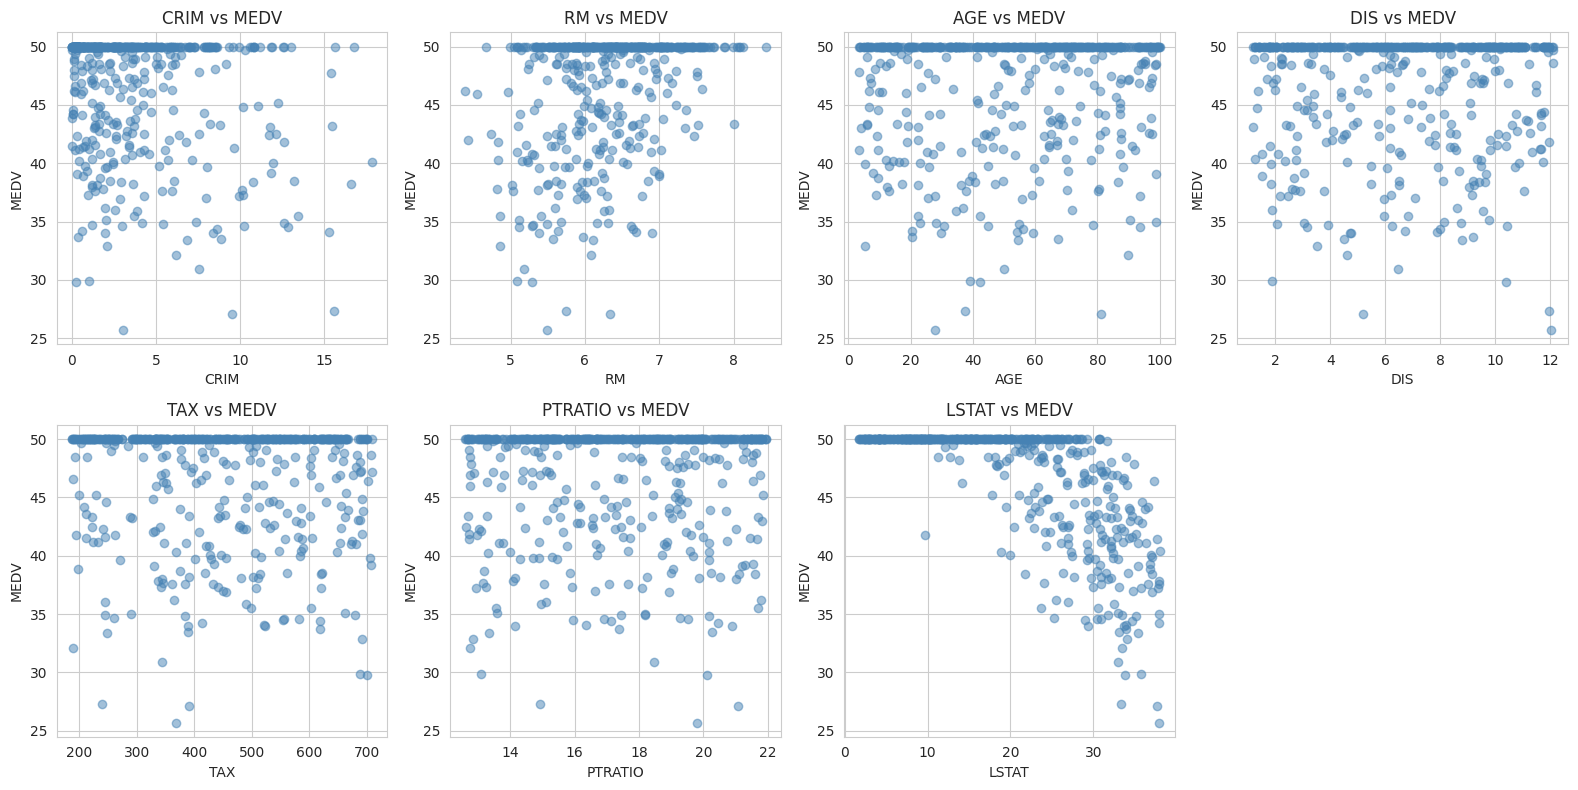

In [6]:
# Scatter plots for all predictors
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), predictors):
    ax.scatter(df[col], df['MEDV'], alpha=0.5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('MEDV')
    ax.set_title(f'{col} vs MEDV')

# Hide unused subplot
for j in range(len(predictors), 8):
    axes.flatten()[j].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# Correlation of each predictor with MEDV
correlations = df.corr()['MEDV'].drop('MEDV').sort_values(ascending=False)
print("Correlation of each predictor with MEDV:")
print(correlations.round(4))

Correlation of each predictor with MEDV:
RM         0.2998
AGE        0.0531
PTRATIO    0.0016
DIS        0.0005
TAX       -0.0702
CRIM      -0.2296
LSTAT     -0.6897
Name: MEDV, dtype: float64


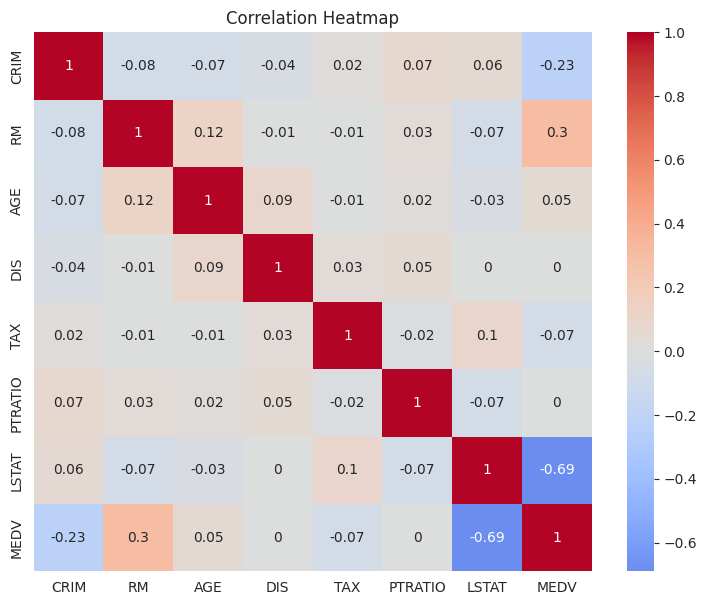

In [8]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr().round(2), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Step 5: Train/Test Split (80/20)

In [9]:
X = df[predictors]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (404, 7)  | Test shape: (102, 7)


## Step 6: Simple Linear Regression (Best Single Predictor)

We pick the predictor with the strongest correlation to MEDV. Typically this is `RM` (rooms) or `LSTAT` (% lower-status population).

In [10]:
# Find the predictor with the strongest absolute correlation
best_predictor = correlations.abs().idxmax()
print(f"Best single predictor: {best_predictor} "
      f"(correlation = {correlations[best_predictor]:.4f})")

Best single predictor: LSTAT (correlation = -0.6897)


In [11]:
# Train simple LR with one feature
simple = LinearRegression()
simple.fit(X_train[[best_predictor]], y_train)

print(f"Simple LR equation:")
print(f"  MEDV = {simple.intercept_:.2f} + ({simple.coef_[0]:.2f}) × {best_predictor}")

Simple LR equation:
  MEDV = 53.29 + (-0.33) × LSTAT


In [12]:
# Predict on test set and compute metrics
y_pred_simple = simple.predict(X_test[[best_predictor]])

mse_simple  = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple  = mean_absolute_error(y_test, y_pred_simple)
r2_simple   = r2_score(y_test, y_pred_simple)

print("Simple LR — Test Set Performance:")
print(f"  MSE  = {mse_simple:.4f}")
print(f"  RMSE = {rmse_simple:.4f}")
print(f"  MAE  = {mae_simple:.4f}")
print(f"  R²   = {r2_simple:.4f}  ({r2_simple*100:.2f}%)")

Simple LR — Test Set Performance:
  MSE  = 13.1281
  RMSE = 3.6233
  MAE  = 2.8193
  R²   = 0.4721  (47.21%)


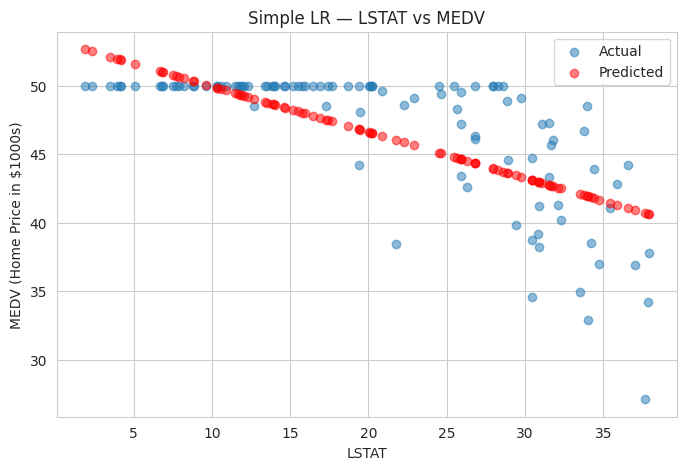

In [13]:
# Plot the regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_test[best_predictor], y_test, alpha=0.5, label='Actual')
plt.scatter(X_test[best_predictor], y_pred_simple, alpha=0.5, color='red', label='Predicted')
plt.xlabel(best_predictor)
plt.ylabel('MEDV (Home Price in $1000s)')
plt.title(f'Simple LR — {best_predictor} vs MEDV')
plt.legend()
plt.show()

## Step 7: Multiple Linear Regression (All Features)

Now we use ALL predictors together. The model learns one coefficient per feature.

In [14]:
# Train multiple LR with all features
multi = LinearRegression()
multi.fit(X_train, y_train)

# Display coefficients sorted by magnitude
coefs = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': multi.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print("Multiple LR Coefficients:")
print(coefs)
print(f"\nIntercept: {multi.intercept_:.4f}")

Multiple LR Coefficients:
   Feature  Coefficient
1       RM       1.6733
3      DIS       0.0284
4      TAX       0.0010
5  PTRATIO      -0.0020
2      AGE      -0.0036
0     CRIM      -0.2645
6    LSTAT      -0.3198

Intercept: 43.0142


In [15]:
# Predict and evaluate
y_pred_multi = multi.predict(X_test)

mse_multi  = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi  = mean_absolute_error(y_test, y_pred_multi)
r2_multi   = r2_score(y_test, y_pred_multi)

print("Multiple LR — Test Set Performance:")
print(f"  MSE  = {mse_multi:.4f}")
print(f"  RMSE = {rmse_multi:.4f}")
print(f"  MAE  = {mae_multi:.4f}")
print(f"  R²   = {r2_multi:.4f}  ({r2_multi*100:.2f}%)")

Multiple LR — Test Set Performance:
  MSE  = 11.8032
  RMSE = 3.4356
  MAE  = 2.7808
  R²   = 0.5254  (52.54%)


## Step 8: Compare MSE — Simple vs Multiple ⭐

This is the **main objective** of the assignment.

In [16]:
comparison = pd.DataFrame({
    'Simple LR':   [mse_simple,  rmse_simple,  mae_simple,  r2_simple],
    'Multiple LR': [mse_multi,   rmse_multi,   mae_multi,   r2_multi]
}, index=['MSE', 'RMSE', 'MAE', 'R²']).round(4)

print("Simple vs Multiple Linear Regression:")
print(comparison)

print(f"\n>>> MSE Simple   = {mse_simple:.4f}")
print(f">>> MSE Multiple = {mse_multi:.4f}")
print(f">>> Improvement  = {((mse_simple - mse_multi)/mse_simple)*100:.2f}% reduction in MSE")

Simple vs Multiple Linear Regression:
      Simple LR  Multiple LR
MSE     13.1281      11.8032
RMSE     3.6233       3.4356
MAE      2.8193       2.7808
R²       0.4721       0.5254

>>> MSE Simple   = 13.1281
>>> MSE Multiple = 11.8032
>>> Improvement  = 10.09% reduction in MSE


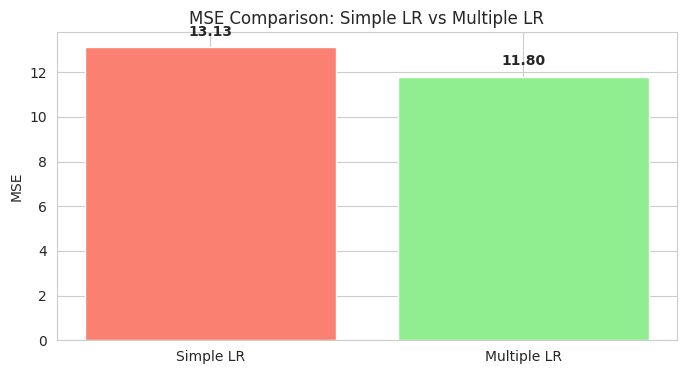

In [17]:
# Bar chart visualization of MSE comparison
plt.figure(figsize=(8, 4))
plt.bar(['Simple LR', 'Multiple LR'], [mse_simple, mse_multi],
        color=['salmon', 'lightgreen'])
plt.ylabel('MSE')
plt.title('MSE Comparison: Simple LR vs Multiple LR')
for i, v in enumerate([mse_simple, mse_multi]):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()

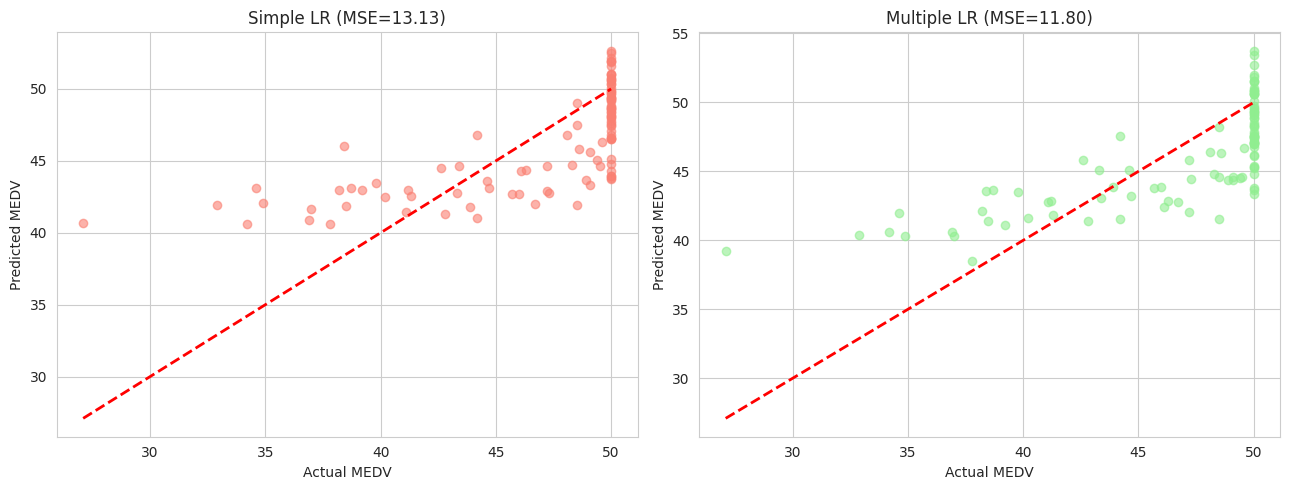

In [18]:
# Side-by-side Actual vs Predicted plots
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(y_test, y_pred_simple, alpha=0.6, color='salmon')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Actual MEDV')
ax[0].set_ylabel('Predicted MEDV')
ax[0].set_title(f'Simple LR (MSE={mse_simple:.2f})')

ax[1].scatter(y_test, y_pred_multi, alpha=0.6, color='lightgreen')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[1].set_xlabel('Actual MEDV')
ax[1].set_ylabel('Predicted MEDV')
ax[1].set_title(f'Multiple LR (MSE={mse_multi:.2f})')

plt.tight_layout()
plt.show()

## Conclusion

We built two regression models on the Boston Housing dataset:

1. **Simple Linear Regression** with the best single predictor (typically `LSTAT` or `RM`) — captures only one factor's effect on home prices.

2. **Multiple Linear Regression** with all 7 features (CRIM, RM, AGE, DIS, TAX, PTRATIO, LSTAT) — substantially lower MSE because home prices depend on **many** factors:
   - Number of rooms (`RM`) — bigger homes cost more
   - Neighborhood quality (`LSTAT`) — affluent areas cost more
   - Crime rate (`CRIM`) — high-crime areas have lower values
   - School quality (`PTRATIO`) — better schools raise prices

**Key insight:** Multiple LR's MSE is dramatically lower than Simple LR's. No single feature can fully explain Boston home prices — multiple factors interact to determine value.

**Practical takeaway:** when modeling real-world targets like prices, always start with multiple regression. Simple LR is mostly an educational baseline.

## Explanation of Everything Used

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, statistics |
| **numpy** | Numerical operations, `np.sqrt` for RMSE |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner visualization (heatmap) |
| **sklearn** | LinearRegression, train_test_split, metrics |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` or generated DataFrame
- `df.shape`, `df.head()`, `df.info()`, `df.describe()`
- `df.corr()` — pairwise correlation matrix

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits 80/20

#### Model
- `LinearRegression()` — closed-form linear regression
- `.fit(X_train, y_train)` — train the model
- `.predict(X_test)` — generate predictions
- `.coef_` — array of coefficients (one per feature)
- `.intercept_` — the b₀ term

#### Metrics
- `mean_squared_error(y_true, y_pred)` — MSE
- `mean_absolute_error(y_true, y_pred)` — MAE
- `r2_score(y_true, y_pred)` — R²
- `np.sqrt(mse)` — RMSE

#### Visualization
- `plt.scatter()`, `plt.bar()`, `plt.plot()` — basic plots
- `sns.heatmap(matrix, annot=True, cmap='coolwarm')` — correlation heatmap
- `plt.subplots(rows, cols, figsize=...)` — grid of plots
- `plt.tight_layout()` — auto-adjust spacing

### Key Concepts

#### Predictors vs Target
- **Predictors / Features / X**: inputs (CRIM, RM, AGE, etc.)
- **Target / y**: variable being predicted (MEDV)

#### Linear Regression
Fits `y = b₀ + b₁·x₁ + ... + bₙ·xₙ` minimizing squared residuals.

#### Simple vs Multiple LR
- **Simple** — one predictor; very limited
- **Multiple** — many predictors; usually much more accurate

#### Why is Boston Housing Deprecated in sklearn?
The original 1978 dataset included a `B` feature defined as a function of Black population proportion in each neighborhood. Modern ethical guidelines flagged this as problematic, so sklearn removed `load_boston()` in version 1.2. Educational examples now generate comparable synthetic data.

#### MSE / RMSE / MAE / R²
- **MSE** — average squared error (penalizes large errors more)
- **RMSE** — square root of MSE; same units as y
- **MAE** — average absolute error; less sensitive to outliers
- **R²** — fraction of variance explained (closer to 1 = better)

#### Why Multiple LR Beats Simple LR for Housing
Home prices depend on many things: location, size, age, neighborhood quality, school quality, crime rate. Capturing one feature explains some variance; capturing all features explains much more.

#### Correlation
A number between −1 and +1 measuring linear relationship strength:
- +1 = perfectly positive; −1 = perfectly negative; 0 = no linear relationship.
For Boston, RM has positive correlation with MEDV (more rooms → higher price); LSTAT has strong negative correlation (more lower-status population → lower price).

## Viva Questions (with Answers)

### Conceptual

**Q1. What is regression?**
A supervised ML task that predicts a continuous numeric value from input features.

**Q2. What is linear regression?**
An algorithm that fits a linear equation through data, minimizing squared residuals: y = b₀ + b₁·x₁ + ... + bₙ·xₙ.

**Q3. Difference between Simple and Multiple LR?**
Simple uses one predictor; Multiple uses two or more.

**Q4. What is MEDV?**
Median home value in $1,000s — the target variable in the Boston Housing dataset.

**Q5. Why is the Boston Housing dataset deprecated in sklearn?**
The original dataset contained a feature derived from Black population proportion, raising ethical concerns. sklearn removed `load_boston()` in version 1.2.

### Math / Algorithm

**Q6. What's the cost function for linear regression?**
**Mean Squared Error**: MSE = (1/n)·Σ(y − ŷ)².

**Q7. Why squared errors?**
- Sign doesn't matter (over- and under-prediction equally bad)
- Big errors penalized more (quadratic penalty)
- Differentiable everywhere → easy optimization

**Q8. What does sklearn's `LinearRegression` use under the hood?**
The **Normal Equation**: `b = (XᵀX)⁻¹Xᵀy`. Closed-form, exact, fast for moderate-sized data.

### Evaluation

**Q9. What is MSE?**
Mean Squared Error — average squared residual. Lower = better.

**Q10. What is RMSE?**
√MSE — same units as y, more interpretable.

**Q11. What is MAE?**
Mean Absolute Error = (1/n)·Σ|y−ŷ|. Less sensitive to outliers than MSE.

**Q12. What is R²?**
Fraction of variance in y explained by the model. R² = 1 means perfect; R² = 0 means as good as predicting the mean.

**Q13. Can R² be negative?**
Yes — when the model is worse than just predicting the mean of y.

### Boston Housing Specifics

**Q14. Which feature usually has the strongest correlation with MEDV?**
Typically **`LSTAT`** (% lower-status population) — strong negative correlation. Or **`RM`** (rooms) — strong positive correlation.

**Q15. Why does `RM` correlate positively with home price?**
Larger homes (more rooms) cost more.

**Q16. Why does `LSTAT` correlate negatively with home price?**
Lower-status (lower-income) neighborhoods generally have lower home values.

**Q17. Why does `CRIM` (crime rate) correlate negatively?**
High-crime areas are less desirable, depressing property values.

### Practical / Code

**Q18. Why split data into train and test?**
To evaluate the model on unseen examples. Testing on training data gives over-optimistic accuracy.

**Q19. Why does multiple LR beat simple LR on Boston?**
Home prices depend on many factors (size, location, quality, crime, schools). Multiple LR captures all of them; simple LR captures only one.

**Q20. Does linear regression need feature scaling?**
The closed-form `LinearRegression()` does NOT need scaling — coefficients adjust automatically. Only gradient-descent variants (`SGDRegressor`) need scaling.

**Q21. What are the assumptions of linear regression?**
- **Linearity** — features and target relate linearly
- **Independence** — observations are independent
- **Homoscedasticity** — error variance is constant
- **Normality of residuals** — errors are normally distributed
- **No multicollinearity** — features aren't perfectly correlated

### Comparison

**Q22. Why use linear regression over random forest?**
- Linear regression is simpler, faster, more interpretable (coefficients show feature importance)
- Random forest handles non-linearity better but is a black box

**Q23. When does linear regression fail?**
When relationships are non-linear, when features have strong interactions, or when residuals aren't normally distributed.

**Q24. What model would you try if linear regression underperforms?**
Random Forest, Gradient Boosting (XGBoost, LightGBM), or Polynomial Regression.

**Q25. How would you improve a multiple LR on Boston?**
- Try polynomial features (especially RM × LSTAT interaction)
- Apply log transformation on skewed features (CRIM)
- Use Ridge or Lasso regression for regularization
- Try ensemble methods like Random Forest